# SWOT-PACE Data Merging and Processing

To get started you need:
1) SWOT MIOST data - currently available through AVISO+ (https://www.aviso.altimetry.fr/en/data/products/sea-surface-height-products/global/experimental-multimission-gridded-l4-sea-level-heights-and-velocities-with-swot-miost.html)

2) PACE data - available through OB.DAAC (https://oceandata.sci.gsfc.nasa.gov/l3/) or EarthData Search (https://search.earthdata.nasa.gov/search?q=%22PACE_OCI_L4M_MOANA%22 or https://search.earthdata.nasa.gov/search?q=%22PACE_OCI_L3M_CHL%22)

If you want to compare against DUACS SSH, you can download that at the Copernicus Marine Service (https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_MY_008_047/description)

For both SWOT and PACE data, you can work with daily datafiles. DUACS typically comes downloaded as a whole timeseries. Create a new folder for analysis where your notebook is located and download your PACE and SWOT data into folders inside this greater folder. You can also create a folder for DUACS, if appropriate.

## Import necessary libraries

In [442]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
import glob
import matplotlib.path as mpath
import cartopy.crs as ccrs
import pandas as pd
from scipy.spatial import cKDTree
import scipy.ndimage as nd
from matplotlib.colors import LogNorm


## Open data

In [443]:
# Open all SWOT MIOST data and combine it into one data array
ds_swot = xr.open_mfdataset('/Users/lily/Documents/GT/SWOT-PACE/SWOT/dt_global_allsat_phy_l4_*.nc')
# # Open the DUACS data
ds_duacs = xr.open_dataset('/Users/lily/Documents/GT/SWOT-PACE/DUACS/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1767460498139.nc')

# ds_swot = xr.open_mfdataset('/Users/lily/Documents/GT/SWOT-PACE/SWOT_snaps/swot_season/dt_global_allsat_phy_l4_*.nc')
# ds_duacs = xr.open_dataset('/Users/lily/Documents/GT/SWOT-PACE/SWOT_snaps/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1767460498139.nc')

In [444]:
# Create an array of file names in order to get the dates as a coordinate
pace_files = sorted(
    # glob.glob('/Users/lily/Documents/GT/SWOT-PACE/test-merge/PACE_OCI.*.L4m.DAY.MOANA.*.nc')
    glob.glob('/Users/lily/Documents/GT/SWOT-PACE/PACE/PACE_OCI.*.L4m.DAY.MOANA.*.nc')
)

pace_dates = pd.to_datetime(
    [f.split('.')[1] for f in pace_files],
    format='%Y%m%d'
)

pace_filedate = xr.Dataset(
    data_vars=dict(
        file=("time", pace_files)
    ),
    coords=dict(
        time=pace_dates
    )
)

pace_filedate = pace_filedate.sortby("time")

# Open the actual PACE data in one data array
ds_pace = xr.open_mfdataset(
    pace_filedate['file'].values,
    concat_dim='time',
    combine='nested'
)

ds_pace = ds_pace.assign_coords(time=pace_filedate.time.values)

In [445]:
# 5 day rolling average of PACE
pace_5day = ds_pace.rolling(time=5, center=True, min_periods=2).mean(skipna=True)

## Select region of interest

In [446]:
lat_min, lat_max = 30, 40
lon_min, lon_max = -75, -64

In [447]:
def compute_diagnostics_2d(u, v, lat, lon):
    """
    Compute Rossby number and Okubo-Weiss for a single timestep.
    
    Parameters
    ----------
    u, v : 2D DataArray (lat, lon)
    lat, lon : 1D arrays
    
    Returns
    -------
    Ro, OW : 2D DataArray
    """
    
    Omega = 7.292115e-5
    R = 6371000.0

    lat_rad = np.deg2rad(lat.values)
    lon_rad = np.deg2rad(lon.values)
    
    dlat = np.gradient(lat_rad)
    dlon = np.gradient(lon_rad)
    
    dx = (R * np.cos(lat_rad))[:, None] * dlon[None, :]
    dy = (R * dlat)[:, None] * np.ones(len(lon))[None, :]

    f = 2 * Omega * np.sin(lat_rad)
    f = xr.DataArray(f, coords={"latitude": lat}, dims=["latitude"])
    f = f.broadcast_like(u)
    f = f.where(np.abs(f) > 1e-6)

    
    # convert to numpy for gradients
    u_np = u.values
    v_np = v.values

    du_dlon = np.gradient(u_np, axis=1)
    du_dlat = np.gradient(u_np, axis=0)
    dv_dlon = np.gradient(v_np, axis=1)
    dv_dlat = np.gradient(v_np, axis=0)

    # physical gradients
    du_dx = du_dlon / dx
    du_dy = du_dlat / dy
    dv_dx = dv_dlon / dx
    dv_dy = dv_dlat / dy

    # diagnostics
    s_n = du_dx - dv_dy
    s_s = dv_dx + du_dy
    zeta = dv_dx - du_dy

    OW = s_n**2 + s_s**2 - zeta**2
    Ro = zeta / f.values

    # wrap back into xarray
    Ro_da = xr.DataArray(
        Ro,
        coords={"latitude": lat, "longitude": lon},
        dims=("latitude", "longitude"),
        name="Ro",
    )

    OW_da = xr.DataArray(
        OW,
        coords={"latitude": lat, "longitude": lon},
        dims=("latitude", "longitude"),
        name="OW",
    )

    return Ro_da, OW_da

In [448]:
def compute_diagnostics(ds):
    Ro_list = []
    OW_list = []

    for t in ds.time:
        sub = ds.sel(time=t)

        Ro, OW = compute_diagnostics_2d(
            sub['ugos'],
            sub['vgos'],
            sub['latitude'],
            sub['longitude']
        )

        Ro = Ro.expand_dims(time=[t.values])
        OW = OW.expand_dims(time=[t.values])

        Ro_list.append(Ro)
        OW_list.append(OW)

    Ro_all = xr.concat(Ro_list, dim="time")
    OW_all = xr.concat(OW_list, dim="time")

    ds = ds.copy()
    ds["Ro"] = Ro_all
    ds["OW"] = OW_all

    return ds

In [449]:
swot_sub = ds_swot.where(
    (ds_swot.latitude >= lat_min) & (ds_swot.latitude <= lat_max) &
    (ds_swot.longitude >= lon_min) & (ds_swot.longitude <= lon_max),
    drop=True
)
swot_sub = compute_diagnostics(swot_sub)

duacs_sub = ds_duacs.where(
    (ds_duacs.latitude >= lat_min) & (ds_duacs.latitude <= lat_max) &
    (ds_duacs.longitude >= lon_min) & (ds_duacs.longitude <= lon_max),
    drop=True
)
duacs_sub = compute_diagnostics(duacs_sub)

pace_sub = pace_5day.where(
    (pace_5day.lat >= lat_min) & (pace_5day.lat <= lat_max) &
    (pace_5day.lon >= lon_min) & (pace_5day.lon <= lon_max),
    drop=True
)

## Remove cloudy days and interpolate PACE data to SWOT/DUACS grid

In [450]:
cloud_threshold = 0.5
# compute cloud fraction over same window
var = "prococcus_moana" #representative variable
valid_fraction = pace_sub[var].notnull().mean(dim=("lat", "lon"))
mask = (valid_fraction > cloud_threshold).compute()
pace_sub = pace_sub.sel(time=pace_sub.time[mask])

In [451]:
pace_interp_swot = pace_sub.interp(lat=swot_sub.latitude, lon=swot_sub.longitude)
pace_interp_duacs = pace_sub.interp(lat=duacs_sub.latitude, lon=duacs_sub.longitude)


In [452]:
def closed_contour_mask(F, threshold=0.3):

    low = F < threshold

    boundary = np.zeros_like(F, dtype=bool)
    boundary[0, :] = True
    boundary[-1, :] = True
    boundary[:, 0] = True
    boundary[:, -1] = True

    seed = low & boundary
    structure = np.ones((3, 3))

    open_low = nd.binary_propagation(seed, structure=structure, mask=low)

    inside_closed = low & ~open_low

    return ~(low & ~inside_closed)

In [453]:
def closed_contour_mask_time(field, threshold=0.3):
    return xr.apply_ufunc(
        closed_contour_mask,
        field,
        kwargs={"threshold": threshold},
        input_core_dims=[["latitude", "longitude"]],
        output_core_dims=[["latitude", "longitude"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[bool],
    )

## Binning by Rossby number - one day

In [465]:
date = "2024-06-03"

swot = swot_sub.sel(time=date)
duacs = duacs_sub.sel(time=date)

pace_swot = pace_interp_swot.sel(time=date)
pace_duacs = pace_interp_duacs.sel(time=date)

In [466]:
mask_s = closed_contour_mask_time(swot['adt'], threshold=0.3)
mask_d = closed_contour_mask_time(duacs['adt'], threshold=0.3)

swot_masked = swot.where(mask_s)
duacs_masked = duacs.where(mask_d)

pace_swot_masked = pace_swot.where(mask_s)
pace_duacs_masked = pace_duacs.where(mask_d)

In [467]:
rossby_swot = swot_masked['Ro'].values.flatten()
rossby_duacs = duacs_masked['Ro'].values.flatten()

pro_swot = pace_swot_masked['prococcus_moana'].values.flatten()
syn_swot = pace_swot_masked['syncoccus_moana'].values.flatten()
pico_swot = pace_swot_masked['picoeuk_moana'].values.flatten()

pro_duacs = pace_duacs_masked['prococcus_moana'].values.flatten()
syn_duacs = pace_duacs_masked['syncoccus_moana'].values.flatten()
pico_duacs = pace_duacs_masked['picoeuk_moana'].values.flatten()

In [468]:
def clean_mask(*arrays):
    m = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        m &= ~np.isnan(a)
    return m

In [470]:
mask_swot = clean_mask(rossby_swot, pro_swot, syn_swot, pico_swot) & (pro_swot < 8e5)

rossby_swot = rossby_swot[mask_swot]
pro_swot = pro_swot[mask_swot]
syn_swot = syn_swot[mask_swot]
pico_swot = pico_swot[mask_swot]

mask_duacs = clean_mask(rossby_duacs, pro_duacs, syn_duacs, pico_duacs) & (pro_duacs < 8e5)

rossby_duacs = rossby_duacs[mask_duacs]
pro_duacs = pro_duacs[mask_duacs]
syn_duacs = syn_duacs[mask_duacs]
pico_duacs = pico_duacs[mask_duacs]

In [471]:
def bin_by_x(x, y, bins):
    binned = []
    for i in range(len(bins) - 1):
        m = (x >= bins[i]) & (x < bins[i + 1])
        binned.append(y[m])
    return binned

In [472]:
num_bins = 9
bins = np.linspace(-0.9, 0.9, num_bins + 1)
bin_centers = np.round(0.5 * (bins[:-1] + bins[1:]),decimals=6)

In [473]:
pro_swot_binned = bin_by_x(rossby_swot, pro_swot, bins)
syn_swot_binned = bin_by_x(rossby_swot, syn_swot, bins)
pico_swot_binned = bin_by_x(rossby_swot, pico_swot, bins)

pro_duacs_binned = bin_by_x(rossby_duacs, pro_duacs, bins)
syn_duacs_binned = bin_by_x(rossby_duacs, syn_duacs, bins)
pico_duacs_binned = bin_by_x(rossby_duacs, pico_duacs, bins)

In [474]:
def make_panel(x, y, binned, ylabel, color_scatter, color_median):
    plt.scatter(x, y, s=1, c=color_scatter, alpha=0.3)

    plt.boxplot(
        binned,
        positions=bin_centers,
        widths=(bins[1] - bins[0]) * 0.6,
        showfliers=True,
        medianprops=dict(color=color_median),
        flierprops=dict(marker='.')
    )

    plt.xlim(-1, 1)
    plt.ylabel(ylabel)

### Plot binned data (one day)

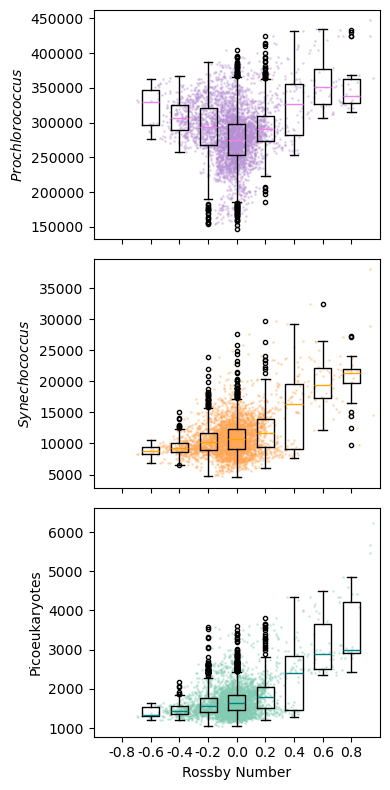

In [475]:
plt.figure(figsize=(4, 8))

plt.subplot(311)
make_panel(
    rossby_swot, pro_swot, pro_swot_binned,
    ylabel=r'$Prochlorococcus$',
    color_scatter='xkcd:pale purple',
    color_median='violet'
)
plt.tick_params(axis='x', labelbottom=False)

plt.subplot(312)
make_panel(
    rossby_swot, syn_swot, syn_swot_binned,
    ylabel=r'$Synechococcus$',
    color_scatter='xkcd:pale orange',
    color_median='orange'
)
plt.tick_params(axis='x', labelbottom=False)

plt.subplot(313)
make_panel(
    rossby_swot, pico_swot, pico_swot_binned,
    ylabel='Picoeukaryotes',
    color_scatter='xkcd:pale teal',
    color_median='teal'
)
plt.xlabel('Rossby Number')

plt.tight_layout()
plt.show()

### Plot maps of data

([<matplotlib.axis.YTick at 0x69402c0d0>,
 [Text(0, 30, '30$^\\circ$N'),
  Text(0, 35, '35$^\\circ$N'),
  Text(0, 40, '40$^\\circ$N')])

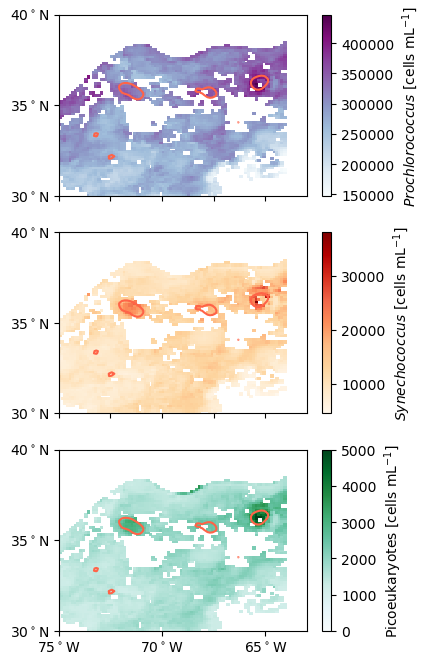

In [476]:
plt.figure(figsize=(4,8))
plt.subplot(311)
plt.contour(swot_masked.longitude,swot_masked.latitude,swot_masked.Ro,levels=[.4],colors='tomato')
plt.plot([0,1],[0,1],c='tomato',linewidth=2,label='SWOT; Ro > 0.4')
#plt.pcolor(mean_sub.lon,mean_sub.lat,mean_sub.chlor_a,cmap='YlGn',norm=LogNorm(vmin=vmin, vmax=vmax),)
plt.pcolor(pace_swot_masked.lon,pace_swot_masked.lat,pace_swot_masked.prococcus_moana,cmap='BuPu')
plt.colorbar(label='$Prochlorococcus$ [cells mL$^{-1}$]',location='right')
#plt.clim(0,5000)
plt.xlim(-75,-63)
plt.ylim(30,40)
plt.tick_params(axis='x', labelbottom=False)
plt.yticks([30,35,40],['30$^\circ$N','35$^\circ$N','40$^\circ$N'])

plt.subplot(312)
plt.contour(swot_masked.longitude,swot_masked.latitude,swot_masked.Ro,levels=[.4],colors='tomato')
plt.plot([0,1],[0,1],c='tomato',linewidth=2,label='SWOT; Ro > 0.4')
#plt.pcolor(mean_sub.lon,mean_sub.lat,mean_sub.chlor_a,cmap='YlGn',norm=LogNorm(vmin=vmin, vmax=vmax),)
plt.pcolor(pace_swot_masked.lon,pace_swot_masked.lat,pace_swot_masked.syncoccus_moana,cmap='OrRd')
plt.colorbar(label='$Synechococcus$ [cells mL$^{-1}$]',location='right')
#plt.clim(0,5000)
plt.xlim(-75,-63)
plt.ylim(30,40)
plt.tick_params(axis='x', labelbottom=False)
plt.yticks([30,35,40],['30$^\circ$N','35$^\circ$N','40$^\circ$N'])

plt.subplot(313)
plt.contour(swot_masked.longitude,swot_masked.latitude,swot_masked.Ro,levels=[.4],colors='tomato')
plt.plot([0,1],[0,1],c='tomato',linewidth=2,label='SWOT; Ro > 0.4')
#plt.pcolor(mean_sub.lon,mean_sub.lat,mean_sub.chlor_a,cmap='YlGn',norm=LogNorm(vmin=vmin, vmax=vmax),)
plt.pcolor(pace_swot_masked.lon,pace_swot_masked.lat,pace_swot_masked.picoeuk_moana,cmap='BuGn')
plt.colorbar(label='Picoeukaryotes [cells mL$^{-1}$]',location='right')
plt.clim(0,5000)
plt.xlim(-75,-63)
plt.ylim(30,40)
plt.xticks([-75,-70,-65],['75$^\circ$W','70$^\circ$W','65$^\circ$W'])
plt.yticks([30,35,40],['30$^\circ$N','35$^\circ$N','40$^\circ$N'])
#plt.colorbar(label='Picoeukaryotes')

([<matplotlib.axis.YTick at 0x699a9d850>,
 [Text(0, 30, '30$^\\circ$N'),
  Text(0, 35, '35$^\\circ$N'),
  Text(0, 40, '40$^\\circ$N')])

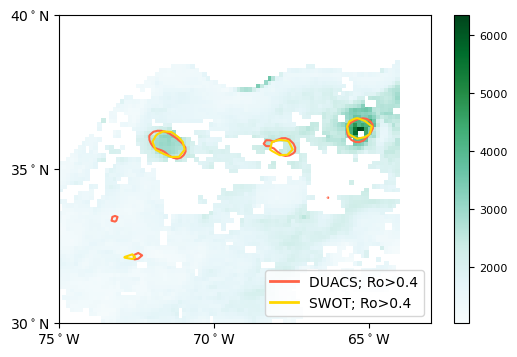

In [478]:
vmin = 0.05
vmax = 2

plt.figure(figsize=(6,4))
plt.contour(swot_masked.longitude,swot_masked.latitude,swot_masked.Ro,levels=[.4],colors='tomato')
plt.contour(duacs_masked.longitude,duacs_masked.latitude,duacs_masked.Ro,levels=[.4],colors='gold')
plt.plot([0,1],[0,1],c='tomato',linewidth=2,label='SWOT; Ro > 0.4')
plt.plot([0,1],[0,1],c='gold',linewidth=2,label='DUACS; Ro > 0.4')
#plt.pcolor(mean_sub.lon,mean_sub.lat,mean_sub.chlor_a,cmap='Greens',norm=LogNorm(vmin=vmin, vmax=vmax))
plt.pcolor(pace_swot_masked.lon,pace_swot_masked.lat,pace_swot_masked.picoeuk_moana,cmap='BuGn')
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=8)
plt.legend({'SWOT; Ro>0.4','DUACS; Ro>0.4'},loc='lower right')
#plt.clim(0,5000)
plt.xlim(-75,-63)
plt.ylim(30,40)
plt.xticks([-75,-70,-65],['75$^\circ$W','70$^\circ$W','65$^\circ$W'],fontsize=10)
plt.yticks([30,35,40],['30$^\circ$N','35$^\circ$N','40$^\circ$N'],fontsize=10)


## Timeseries of data

In [480]:
flattened_data = []

for t in swot_sub.time.values:

    t = pd.to_datetime(t)

    try:
        swot = swot_sub.sel(time=t)
        # duacs = duacs_sub.sel(time=t)
        pace_swot = pace_interp_swot.sel(time=t)
        # pace_duacs = pace_sub_duacs.sel(time=t)
    except KeyError:
        continue

    mask_swot = closed_contour_mask_time(swot['adt'], threshold=0.3)
    # mask_duacs = closed_contour_mask_time(duacs['adt'], threshold=0.3)
    
    swot_masked = swot.where(mask_swot)
    # duacs_masked = duacs.where(mask_duacs)
    
    pace_swot_masked = pace_swot.where(mask_swot)
    # pace_duacs_masked = pace_duacs.where(mask_duacs)

    rossby_swot = swot_masked['Ro'].values.flatten()
    # rossby_duacs = duacs_masked['Ro'].values.flatten()
    
    pro_swot = pace_swot_masked['prococcus_moana'].values.flatten()
    syn_swot = pace_swot_masked['syncoccus_moana'].values.flatten()
    pico_swot = pace_swot_masked['picoeuk_moana'].values.flatten()
    
    # pro_duacs = pace_duacs_masked['prococcus_moana'].values.flatten()
    # syn_duacs = pace_duacs_masked['syncoccus_moana'].values.flatten()
    # pico_duacs = pace_duacs_masked['picoeuk_moana'].values.flatten()

    mask_swot = clean_mask(rossby_swot, pro_swot, syn_swot, pico_swot) & (pro_swot < 8e5)
    
    rossby_swot = rossby_swot[mask_swot]
    pro_swot = pro_swot[mask_swot]
    syn_swot = syn_swot[mask_swot]
    pico_swot = pico_swot[mask_swot]
    
    # mask_duacs = clean_mask(rossby_duacs, pro_duacs, syn_duacs, pico_duacs) & (pro_duacs < 8e5)
    
    # rossby_duacs = rossby_duacs[mask_duacs]
    # pro_duacs = pro_duacs[mask_duacs]
    # syn_duacs = syn_duacs[mask_duacs]
    # pico_duacs = pico_duacs[mask_duacs]

    flattened_data.append(
        xr.Dataset(
            {
                'Ro_swot': ('points_swot', rossby_swot),
                'prococcus_swot': ('points_swot', pro_swot),
                'syncoccus_swot': ('points_swot', syn_swot),
                'picoeuk_swot': ('points_swot', pico_swot),
                # 'Ro_duacs': ('points_duacs', rossby_duacs),
                # 'prococcus_duacs': ('points_duacs', pro_duacs),
                # 'syncoccus_duacs': ('points_duacs', syn_duacs),
                # 'picoeuk_duacs': ('points_duacs', pico_duacs),
            },
            coords={'time': t}
        )
    )


In [481]:
ds_flattened = xr.concat(flattened_data, dim='points_swot')

/var/folders/vd/xrs3z6w105b3f00f4l39r6qh0000gn/T/ipykernel_78632/2598394445.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_flattened = xr.concat(flattened_data, dim='points_swot')


In [482]:
TAXA = ['prococcus', 'syncoccus', 'picoeuk']
MIN_POINTS = 10

def add_daily_coord(ds):
    return ds.assign_coords(date=ds['time'].dt.floor('D'))


def daily_stats(da, min_points=MIN_POINTS):
    grp = da.groupby('date')

    mean = grp.mean(skipna=True)
    std  = grp.std(skipna=True)
    n    = grp.count()
    sem  = std / np.sqrt(n)

    mask = n >= min_points
    return mean.where(mask), sem.where(mask)

In [483]:
ds_high = add_daily_coord(
    ds_flattened.where(ds_flattened['Ro_swot'] > 0.4, drop=True)
)

daily_mean_pro, daily_sem_pro = daily_stats(ds_high['prococcus_swot'])
daily_mean_syn, daily_sem_syn = daily_stats(ds_high['syncoccus_swot'])
daily_mean_pic, daily_sem_pic = daily_stats(ds_high['picoeuk_swot'])

In [484]:
ds_near0 = add_daily_coord(
    ds_flattened.where((-0.1 < ds_flattened['Ro_swot']) & (ds_flattened['Ro_swot'] < 0.1), drop=True)
)

daily_mean_pro2, daily_sem_pro2 = daily_stats(ds_near0['prococcus_swot'])
daily_mean_syn2, daily_sem_syn2 = daily_stats(ds_near0['syncoccus_swot'])
daily_mean_pic2, daily_sem_pic2 = daily_stats(ds_near0['picoeuk_swot'])

In [485]:
daily_mean_pro, daily_mean_pro2 = xr.align(
    daily_mean_pro, daily_mean_pro2, join='outer'
)

daily_mean_syn, daily_mean_syn2 = xr.align(
    daily_mean_syn, daily_mean_syn2, join='outer'
)

daily_mean_pic, daily_mean_pic2 = xr.align(
    daily_mean_pic, daily_mean_pic2, join='outer'
)

daily_sem_pro, daily_sem_pro2 = xr.align(
    daily_sem_pro, daily_sem_pro2, join='outer'
)

daily_sem_syn, daily_sem_syn2 = xr.align(
    daily_sem_syn, daily_sem_syn2, join='outer'
)

daily_sem_pic, daily_sem_pic2 = xr.align(
    daily_sem_pic, daily_sem_pic2, join='outer'
)

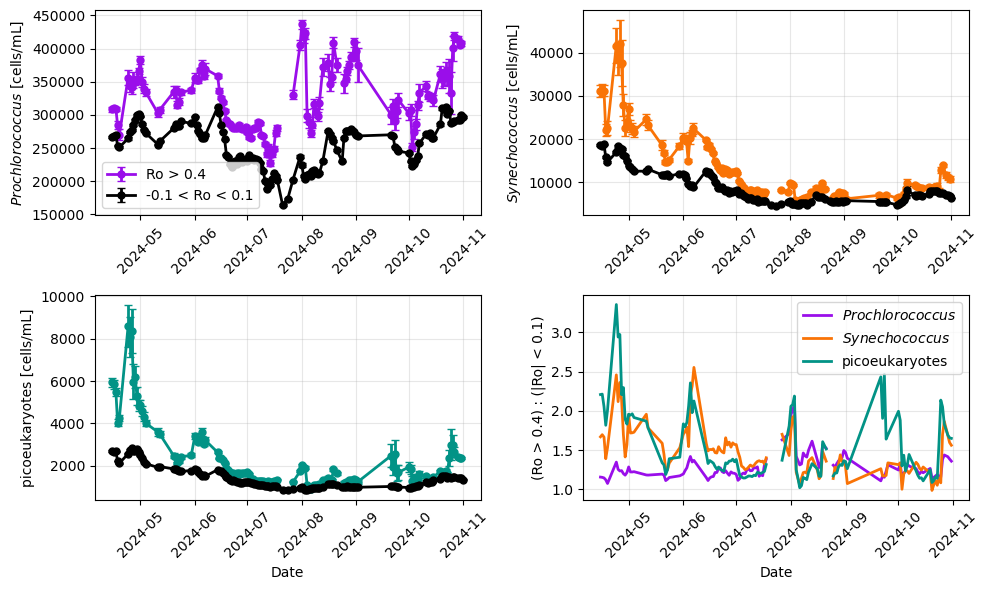

In [486]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

N = 200  # slice length

def plot_err(ax, d1, s1, d2, s2, color, ylabel, label=False):
    ax.errorbar(
        d1['date'].values[:N], d1.values[:N],
        yerr=s1.values[:N],
        fmt='o-', capsize=3, lw=2, c=color, markersize=5,
        label='Ro > 0.4' if label else None
    )
    ax.errorbar(
        d2['date'].values[:N], d2.values[:N],
        yerr=s2.values[:N],
        fmt='o-', capsize=3, lw=2, c='k', markersize=5,
        label='-0.1 < Ro < 0.1' if label else None
    )
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    if label:
        ax.legend(loc='lower left')

# --- Top row ---
plot_err(axes[0], daily_mean_pro, daily_sem_pro,
         daily_mean_pro2, daily_sem_pro2,
         'xkcd:violet', '$Prochlorococcus$ [cells/mL]', label=True)

plot_err(axes[1], daily_mean_syn, daily_sem_syn,
         daily_mean_syn2, daily_sem_syn2,
         'xkcd:orange', '$Synechococcus$ [cells/mL]')

# --- Bottom left ---
plot_err(axes[2], daily_mean_pic, daily_sem_pic,
         daily_mean_pic2, daily_sem_pic2,
         'xkcd:teal', 'picoeukaryotes [cells/mL]')
axes[2].set_xlabel('Date')

# --- Bottom right (ratios) ---
axes[3].plot(daily_mean_pro['date'].values[:N],
             daily_mean_pro.values[:N] / daily_mean_pro2.values[:N],
             lw=2, c='xkcd:violet', label='$Prochlorococcus$')

axes[3].plot(daily_mean_syn['date'].values[:N],
             daily_mean_syn.values[:N] / daily_mean_syn2.values[:N],
             lw=2, c='xkcd:orange', label='$Synechococcus$')

axes[3].plot(daily_mean_pic['date'].values[:N],
             daily_mean_pic.values[:N] / daily_mean_pic2.values[:N],
             lw=2, c='xkcd:teal', label='picoeukaryotes')

axes[3].set_ylabel('(Ro > 0.4) : (|Ro| < 0.1)')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)
axes[3].legend()
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()